# 2.1 Логистическая регрессия. Постановка задачи

## Основные определения и тезисы:   
**Логистическая регрессия** - используется для анализа зависимости между номинативной зависимой переменной и одной или несколькими независимыми переменными(могут быть как номинативными, так и количественными).

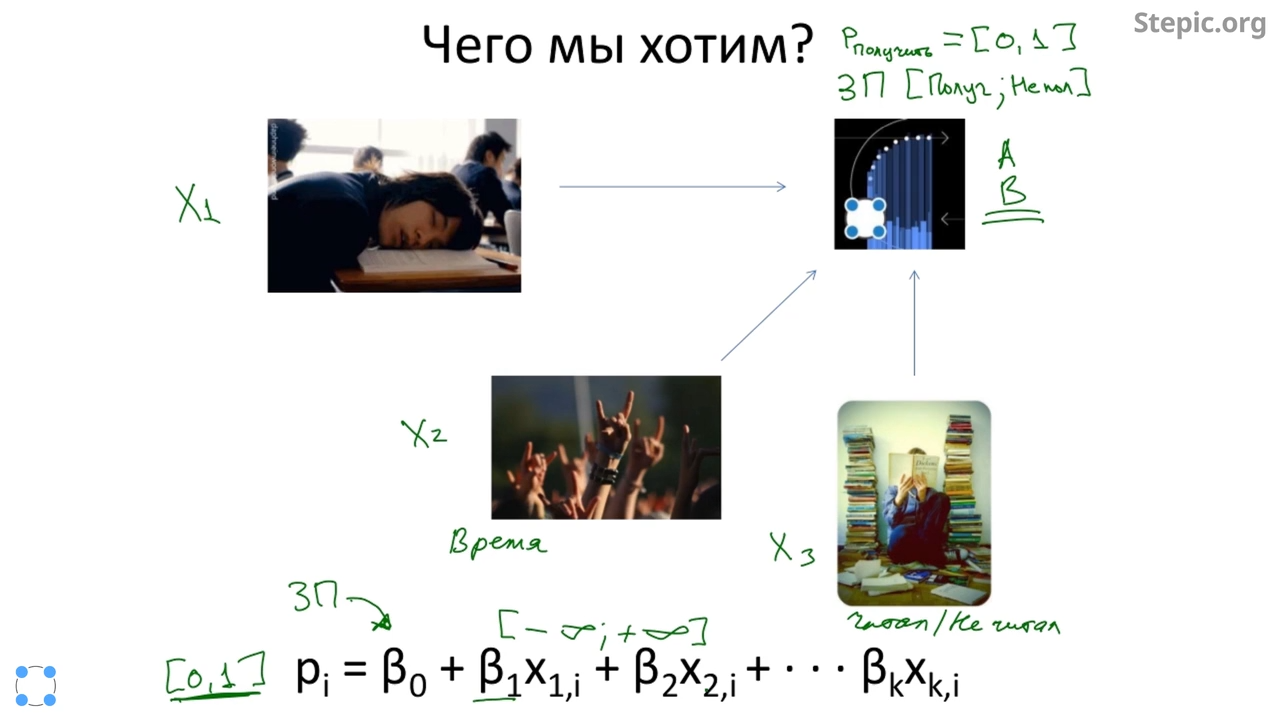

**Odds** - шанс, отношение вероятности успеха Y=1 к вероятности неудачи (Y=0). Принимает значения от 0 до +∞. Если odds > 1, то вероятность положительного исхода больше вероятности отрицательного. Если значения шансов равно единице, то вероятности положительного и отрицательного исхода равны;

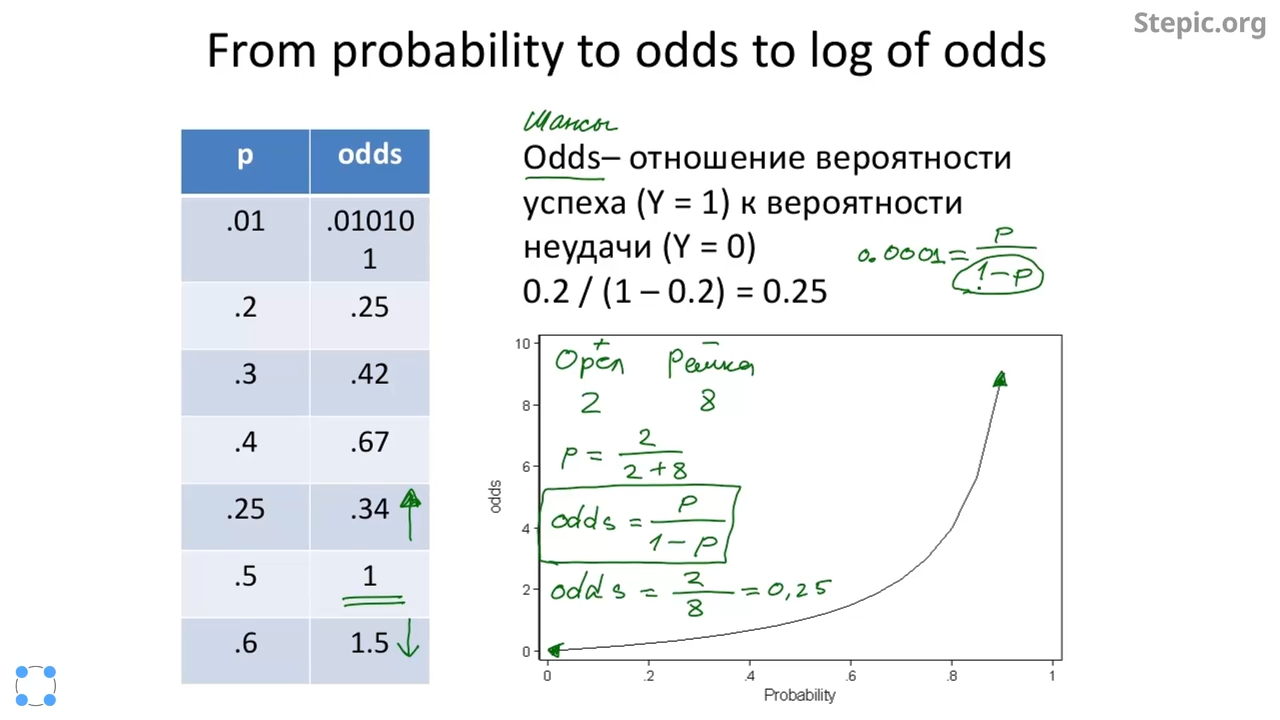

In [28]:
import math
a = math.log(0.3)
a

-1.2039728043259361

**log(odds)** - натуральный логарифм шансов. Принимает значения от -∞ до +∞.  
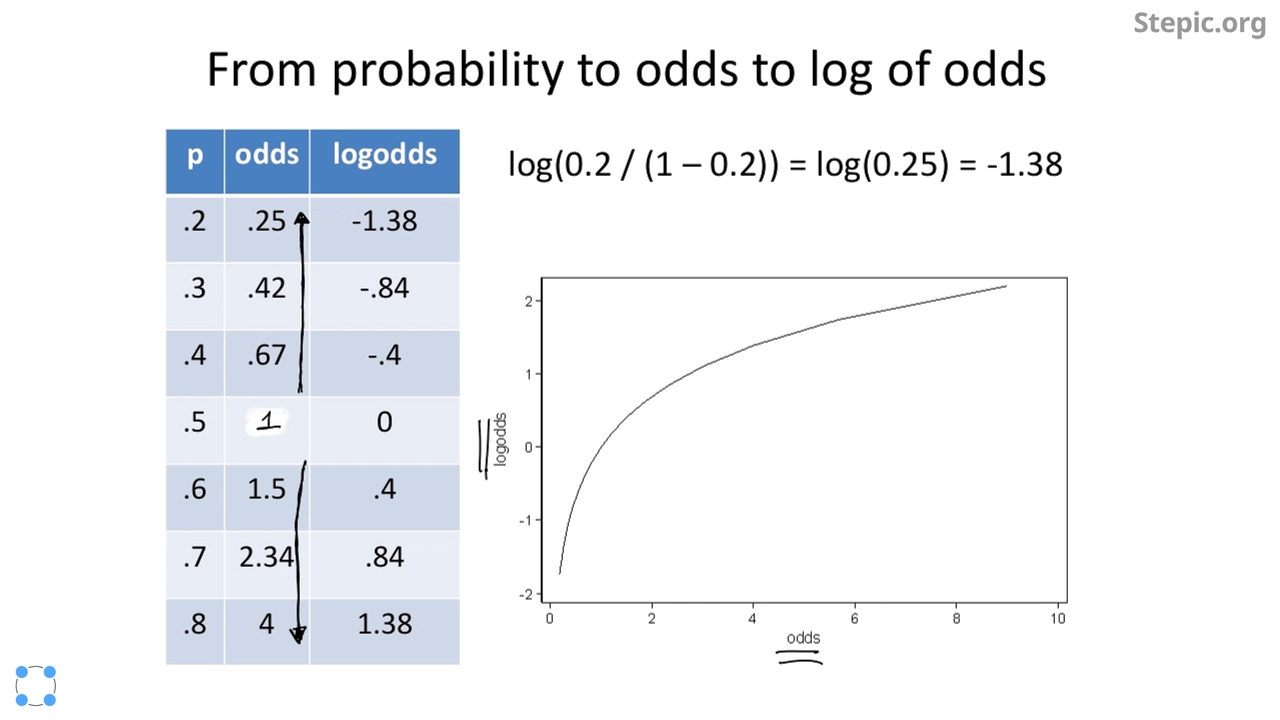
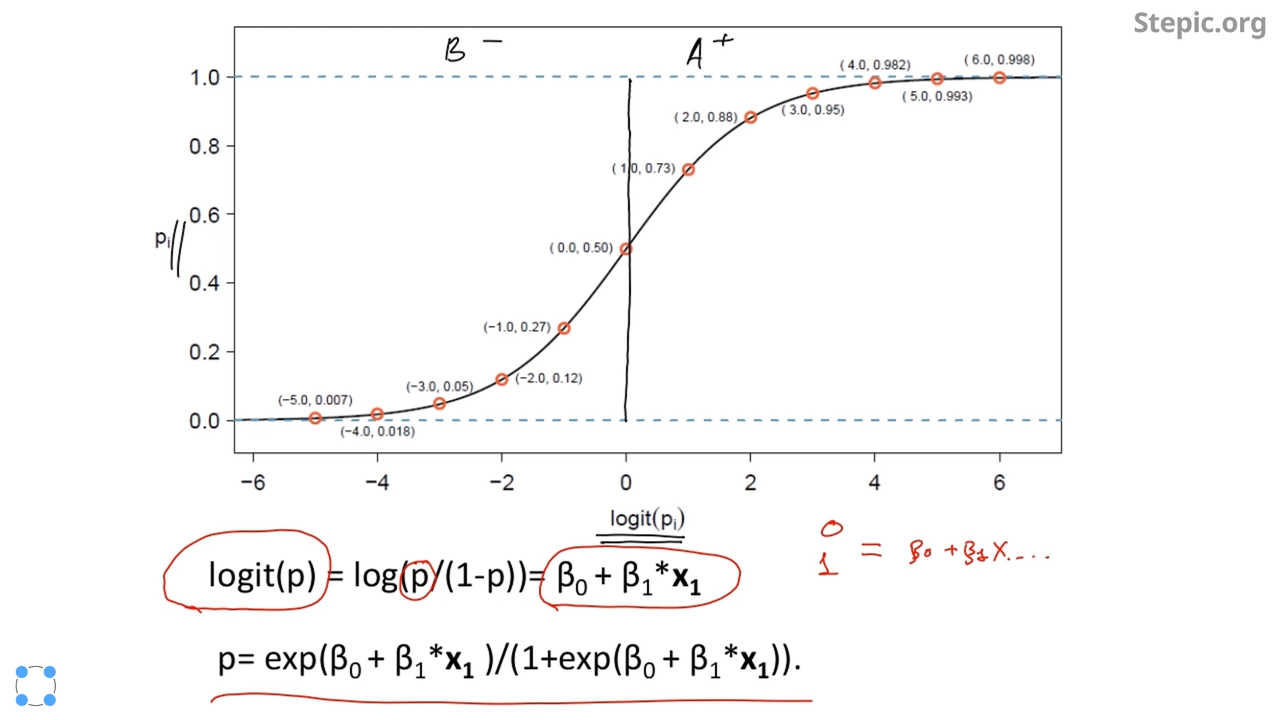

## Задача 1
Предположим, мы подбросили монетку 100 раз, и 70 раз выпал орел. Чему равняется натуральный логарифм шансов выпадения решки?

Чтобы не запутаться, давайте в этом задании рассматривать как "успех" - выпадение решки.

In [45]:
P_pos = 30/100
P_neg = (100-30)/100

odds = P_pos/P_neg
log_odds = math.log(odds)
print(odds)
print(log_odds)

0.4285714285714286
-0.8472978603872036


## Задача 2

Предположим, что мы получили логарифм шансов выпадения решки, равный -1. Тогда вероятность выпадения решки равняется:

In [54]:
log_odds = -1
odds = math.exp(log_odds)
p = odds / (1 + odds) # выводится из формулы
print(p)

0.2689414213699951


## Задача 3

Вернемся к уже знакомым нам данным.
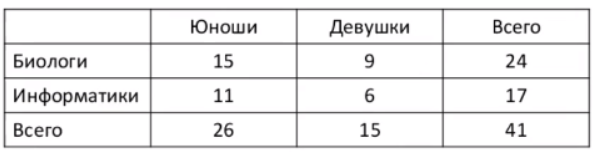
Рассчитайте логарифм шанса, того что случайно выбранный человек из нашей выборки окажется биологом.

In [61]:
pos = 24/41
neg = 17/41

odds = pos/neg

log_odds = math.log(odds)
print(log_odds)

0.3448404862917296


# 2.2 Модель без предикторов. Intercept only model

In [66]:
import numpy as np
import pandas as pd

import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [77]:
# Data
titanic_df = pd.read_csv('https://stepic.org/media/attachments/course/524/train.csv')
titanic_df = titanic_df[titanic_df.Age.notnull()]
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Обобщенные линейные модели (GLM)** — это мощное семейство статистических моделей, которые могут обрабатывать широкий спектр типов данных и переменных отклика. GLM являются расширением модели линейной регрессии и используются, когда переменная ответа не имеет нормального распределения или имеет нелинейную связь с переменными-предикторами. 

In [96]:
# Intercept это и есть логарифм шансов положительного исхода
# Чтобы рассчитать шанс положительного исхода нужно рассчитать экспоненту значения intercept, т.е e в степени intercept

glm = smf.glm(formula='Survived~1', data=titanic_df, family=sm.families.Binomial()).fit()
glm.summary()
# ВЫВОД:
# P>|z| < 0.05 - intercept значимо отличается от нуля  ->
# log_odds значимо меньше нуля ->
# odds < 1 ->
# p выжить значимо меньше, чем p не выжить

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      713
Model Family:                Binomial   Df Model:                            0
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -482.26
Date:                Wed, 23 Jul 2025   Deviance:                       964.52
Time:                        15:17:55   Pearson chi2:                     714.
No. Iterations:                     4   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3799      0.076     -4.985      0.000      -0.529      -0.230
==============================================================================
"""

In [104]:
titanic_df.Survived.value_counts()

Survived
0    424
1    290
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

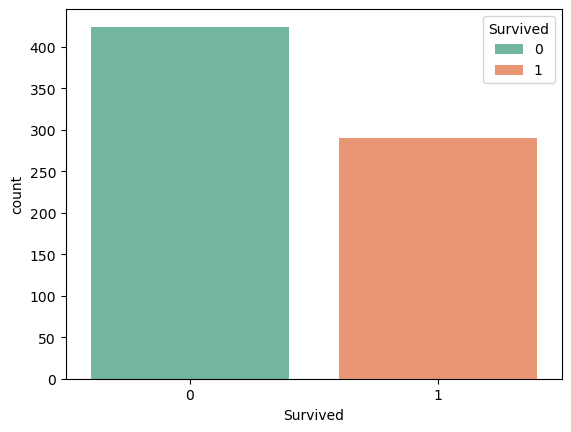

In [133]:
sns.countplot(x='Survived', data=titanic_df, palette = 'Set2', hue = 'Survived')

In [139]:
# Рассчитать шанс (odds)
odds = titanic_df.Survived.value_counts()[1]/titanic_df.Survived.value_counts()[0]
odds

0.6839622641509434

In [144]:
# Логарифм шанса положительного исхода(Intercept)
log_odds = math.log(odds)
log_odds

-0.37985253225143806

In [147]:
# Вероятность выжить
odds = math.exp(log_odds)
pos = odds / (1 + odds)
pos

0.4061624649859944

## Задача
С помощью логистической регрессии без предикторов мы захотели узнать, правда ли, что сдавая Анатолию Дмитриевичу, легче провалить экзамен, чем сдать. В нашей выборке было 50 студентов. Часть из них сдала экзамен (положительный исход), а часть - нет (отрицательный исход). Свободный член нашей регрессии оказался равен -0.8472979. Сколько человек всё-таки сдало экзамен?

In [162]:
log_odds = -0.84
odds = math.exp(log_odds)
print(odds)

0.43171052342907973


In [164]:
#pos/1-pos = odds
pos = odds / (1 + odds)
pos

0.30153478399746125

In [169]:
n=50
print(f'{pos*n} человек сдало экзамен')

15.076739199873062 человек сдало экзамен


# 2.3 Модель с одним номинативным предиктором

In [173]:
# Data
titanic_df = pd.read_csv('https://stepic.org/media/attachments/course/524/train.csv')
titanic_df = titanic_df[titanic_df.Age.notnull()]
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [176]:
glm = smf.glm(formula='Survived~C(Sex)', data=titanic_df, family=sm.families.Binomial()).fit()
glm.summary()

### coef:
# Intercept      - логарифм шанса выжить для женщин, 1.1243 значит шанс больше 1, значит вероятность выжить больше вероятности погибнуть
# C(Sex)[T.male] - логарифм отношения шансов выжить для мужчин к шансам для женщин, -2.4778 значит шанс меньше 1, значит вероятность выжить меньше 
#вероятности погибнуть

# C(Sex)[T.male] = -2.47 - если пассажир мужчина, то вероятность выжить сильно уменьшается

### P>|z|
# Intercept < 0.05 - логарифм шанса выжить для женщин значимо больше 0(вероятность выжить больше чем погибнуть)
# C(Sex)[T.male] < 0.05 -> log(odds_male/odds_female) < 0 ->
# odds_male < 1 ->
# odds_male < odds_female - шансы выжить для женщин значимо больше 

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      712
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -375.35
Date:                Wed, 23 Jul 2025   Deviance:                       750.70
Time:                        17:37:38   Pearson chi2:                     714.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2588
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1243      0.144      7.814      0.000       0.842       1.406
C(Sex)[T.male]    -2.4778      0.185    -13.392      0.000      -2.840      -2.115
==================================================================================
"""

In [179]:
# таблица сопряженности между полом и выжил ли человек 
crosstable = pd.crosstab(titanic_df.Survived, titanic_df.Sex)
crosstable

Sex,female,male
Survived,,
0,64,360
1,197,93


In [184]:
odds_f = crosstable.female[1]/crosstable.female[0]
print(odds_f)

odds_m = crosstable.male[1]/crosstable.male[0]
print(odds_m)

3.078125
0.25833333333333336


In [186]:
log_odds_f=math.log(odds_f)
print(log_odds_f) # значение intercept в модели
log_odds_m=math.log(odds_m)
print(log_odds_m)

1.1243206453783166
-1.3535045382968995


In [197]:
odds_ratio = odds_m/odds_f # вероятность выжить у женщин выше, чем у мужчин
log_odds_ratio = math.log(odds_ratio)
print(log_odds_ratio)

-2.4778251836752165


## Регрессионное уравнение

In [ ]:
# Модель:
# log(odds) = 1.1243 - (2.4778 * Sex_male)

# Если предсказывается логарифм шансов для женщин (Sex_male = 0):
# log(odds) = 1.1243 - (2.4778 * 0)
# log(odds) = 1.1243

# Если предсказывается логарифм шансов для мужчин (Sex_male = 1):
# log(odds) = 1.1243 - (2.4778 * 1)
# log(odds) = 1.1243 - 2.4778
# log(odds) -1.3535

## Задача 1
Рассчитайте значение экспоненты коэффициентов модели, в поле для ответа введите сумму получившихся чисел.

In [225]:
intercept = glm.params.iloc[0]
Sex_male = glm.params.iloc[1]

print(math.exp(intercept))
print(math.exp(Sex_male))
math.exp(intercept) + math.exp(Sex_male)

3.078124999991267
0.0839255499156679


3.162050549906935

## Задача 2
Во сколько раз шансы выжить для женщин превышают шансы выжить для мужчин?

In [240]:
print(log_odds_ratio) # логарифм отношения шансов выжить у мужчин к шансам выжить у женчин
print(odds_m)
print(odds_f)
odds_f/odds_m

-2.4778251836752165
0.25833333333333336
3.078125


11.91532258064516

# 2.4 Модель с двумя номинативными предикторами

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [9]:
# Data
titanic_df = pd.read_csv('https://stepic.org/media/attachments/course/524/train.csv')
titanic_df = titanic_df[titanic_df.Age.notnull()]
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
glm_2 = smf.glm(formula='Survived ~ C(Sex) * C(Pclass)', data=titanic_df, family=sm.families.Binomial()).fit()
glm_2.summary()

### Coef:
# Intercept                     - логарифм шансов положительного исхода для женщин в 1 классе.
# C(Sex)[T.male]                - логарифм отношения шансов для мужчин в первом классе и женщин в первом классе.
# C(Pclass)[T.2]                - логарифм отношения шансов для женщин во втором классе и женщин в первом классе.
# C(Pclass)[T.3]                - логарифм отношения шансов для женщин в третьем классе и женщин в первом классе.

### P>|z|:
# C(Sex)[T.male] / P>|z| < 0.05 -> Шансы выжить у мужчин 1 класса меньше чем у женщин 1 класса
# C(Pclass)[T.2] / P>|z| > 0.05 -> значение статистически не значимо (шанс выжить в 1 и 2 классе почти не отличается)
# C(Pclass)[T.3] / P>|z| < 0.05 -> Шансы выжить в 3 классе значительно меньше чем в 1 классе

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      708
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -321.14
Date:                Thu, 24 Jul 2025   Deviance:                       642.28
Time:                        11:38:54   Pearson chi2:                     714.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3632
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         3.3081      0.588      5.628      0.000       2.156       4.460
C(Sex)[T.male]                   -3.7301      0.622     -5.997      0.000      -4.949      -2.511
C(Pclass)[T.2]                   -0.8804      0.726     -1.213      0.225      -2.303       0.542
C(Pclass)[T.3]                   -3.4653      0.620     -5.585      0.000      -4.681      -2.249
C(Sex)[T.male]:C(Pclass)[T.2]    -0.4204      0.804     -0.523      0.601      -1.997       1.156
C(Sex)[T.male]:C(Pclass)[T.3]     2.1542      0.676      3.185      0.001       0.829       3.480
=================================================================================================
"""

## Интерпретация коэффициентов

In [25]:
# Таблица сопряженности между переменными выжил/не выжил и классом пассажира для женщин.
crosstable_f = pd.crosstab(titanic_df[titanic_df.Sex == 'female'].Survived, titanic_df.Pclass)
crosstable_f

Pclass,1,2,3
Survived,,,
0,3,6,55
1,82,68,47


In [27]:
# Таблица сопряженности между переменными выжил/не выжил и классом пассажира для мужчин.
crosstable_m = pd.crosstab(titanic_df[titanic_df.Sex == 'male'].Survived, titanic_df.Pclass)
crosstable_m

Pclass,1,2,3
Survived,,,
0,61,84,215
1,40,15,38


In [44]:
# Intercept - логарифм шансов положительного исхода для женщин в первом классе
odds_female_firts = crosstable_f.iloc[1, 0]/crosstable_f.iloc[0,0]
print(f'odds_female_firts: {odds_female_firts}')
logs_odds_female_firts = np.log(odds_female_firts)
print(f'logs_odds_female_firts: {logs_odds_female_firts}')

odds_female_firts: 27.333333333333332
logs_odds_female_firts: 3.3081069585961433


In [55]:
#C(Sex)[T.male] - логарифм отношения шансов выжить у мужчин первого класса к женщинам первого класса 
odds_male_firts = crosstable_m.iloc[1, 0]/crosstable_m.iloc[0,0]
print(f'odds_male_firts: {odds_male_firts}')
logs_m1_f1 = np.log(odds_male_firts/odds_female_firts)
print(f'logs_m1_f1: {logs_m1_f1}')

odds_male_firts: 0.6557377049180327
logs_m1_f1: -3.7301013686555184


In [66]:
# C(Pclass)[T.2] - логарифм отношения шансов для женщин во втором классе и женщин в первом классе.
odds_female_second = crosstable_f.iloc[1, 1]/crosstable_f.iloc[0,1]
print(f'odds_female_second: {odds_female_second}')
logs_f2_f1 = np.log(odds_female_second/odds_female_firts)
print(f'logs_f2_f1: {logs_f2_f1}')

odds_female_second: 11.333333333333334
logs_f2_f1: -0.8803587226480917


In [71]:
# C(Pclass)[T.3]- логарифм отношения шансов для женщин в третьем классе и женщин в первом классе.
odds_female_third = crosstable_f.iloc[1, 2]/crosstable_f.iloc[0,2]
print(f'odds_female_third: {odds_female_third}')
logs_f3_f1 = np.log(odds_female_third/odds_female_firts)
print(f'logs_f3_f1: {logs_f3_f1}')

odds_female_third: 0.8545454545454545
logs_f3_f1: -3.4652925421185556


# 2.5 Взаимодействие номинативных предикторов

In [80]:
glm_2 = smf.glm(formula='Survived ~ C(Sex) * C(Pclass)', data=titanic_df, family=sm.families.Binomial()).fit()
glm_2.summary()

# C(Sex)[T.male]:C(Pclass)[T.2] - разность логарифмов отношения шансов, рассчитанных для мужчин и женщин в первом классе и во втором классе.
# C(Sex)[T.male]:C(Pclass)[T.3] - разность логарифмов отношения шансов, рассчитанных для мужчин и женщин в первом и в третьем классе.

### P>|z|:
# C(Sex)[T.male]:C(Pclass)[T.2] / P>|z| > 0.05 -> значение статистически не значимо ->
# пропорции выживших мужчин и женщин в 1 и 2 классе почти не отличаются

# C(Sex)[T.male]:C(Pclass)[T.3] / P>|z| < 0.05 -> Взаимосвязь между полом и выжил или не выжил человек значимо отличаются,
# если сравнивать 1 и 3 класс

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      708
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -321.14
Date:                Thu, 24 Jul 2025   Deviance:                       642.28
Time:                        16:04:24   Pearson chi2:                     714.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3632
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         3.3081      0.588      5.628      0.000       2.156       4.460
C(Sex)[T.male]                   -3.7301      0.622     -5.997      0.000      -4.949      -2.511
C(Pclass)[T.2]                   -0.8804      0.726     -1.213      0.225      -2.303       0.542
C(Pclass)[T.3]                   -3.4653      0.620     -5.585      0.000      -4.681      -2.249
C(Sex)[T.male]:C(Pclass)[T.2]    -0.4204      0.804     -0.523      0.601      -1.997       1.156
C(Sex)[T.male]:C(Pclass)[T.3]     2.1542      0.676      3.185      0.001       0.829       3.480
=================================================================================================
"""

In [82]:
# Таблица сопряженности между переменными выжил/не выжил и классом пассажира для женщин.
crosstable_f = pd.crosstab(titanic_df[titanic_df.Sex == 'female'].Survived, titanic_df.Pclass)
crosstable_f

Pclass,1,2,3
Survived,,,
0,3,6,55
1,82,68,47


In [84]:
# Таблица сопряженности между переменными выжил/не выжил и классом пассажира для мужчин.
crosstable_m = pd.crosstab(titanic_df[titanic_df.Sex == 'male'].Survived, titanic_df.Pclass)
crosstable_m

Pclass,1,2,3
Survived,,,
0,61,84,215
1,40,15,38


## Интерпретация коэффициентов

In [96]:
# C(Sex)[T.male]:C(Pclass)[T.2]
odds_male_second = crosstable_m.iloc[1, 1]/crosstable_m.iloc[0, 1]
print(f'odds_male_second: {odds_male_second}')
print(f'odds_female_second: {odds_female_second}')

odds_male_second: 0.17857142857142858
odds_female_second: 11.333333333333334


In [100]:
print(f'odds_female_firts: {odds_female_firts}')
odds_male_first = crosstable_m.iloc[1, 0]/crosstable_m.iloc[0, 0]
print(f'odds_male_first: {odds_male_first}')

odds_female_firts: 27.333333333333332
odds_male_first: 0.6557377049180327


In [103]:
log_odds_second_first = np.log(odds_male_second/odds_female_second) - np.log(odds_male_first/odds_female_firts)
print(f'log_odds_second_first: {log_odds_second_first}')

log_odds_second_first: -0.42041346503363686


In [108]:
#C(Sex)[T.male]:C(Pclass)[T.3]
odds_male_third = crosstable_m.iloc[1, 2]/crosstable_m.iloc[0, 2]
print(f'odds_male_third: {odds_male_third}')
print(f'odds_female_third: {odds_female_third}')

odds_male_third: 0.17674418604651163
odds_female_third: 0.8545454545454545


In [110]:
log_odds_third_first = np.log(odds_male_third/odds_female_third) - np.log(odds_male_first/odds_female_firts)
print(f'log_odds_third_first: {log_odds_third_first}')

log_odds_third_first: 2.154235083776654


## Интерпретация уравнения регрессии

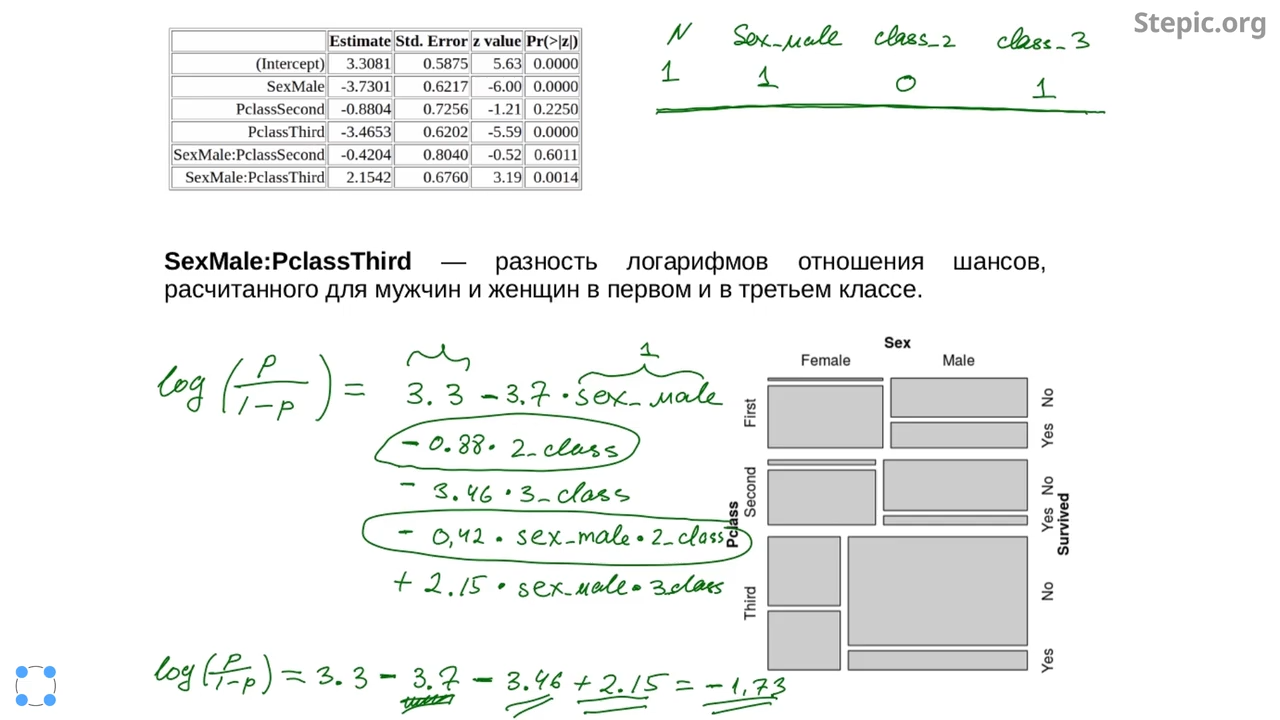

In [121]:
# log(p / (1-p)) = 3.3081 - (3.7301 * Sex_male) - (0.8804 * Pclass2) - (3.4653 * Pclass3) 
# - (0.4204 * Sex_male * Pclass2) + (2.1542 * Sex_male * Pclass3)

# Если предсказывается логарифм шансов для мужчин в 3 классе (Sex_male = 1, Pclass2 = 0, Pclass3 = 1):
# log(odds) = 3.3081 - (3.7301 * 1) - (0.8804 * 0) - (3.4653 * 1) - (0.4204 * 1 * 0) + (2.1542 * 1 * 1) ->
# log(odds) = 3.3081 - 3.7301 - 3.4653 + 2.1542 ->
# log(odds) = -1.7331
odds = np.exp(-1.7331)
print("Шанс выжить мужчине из 3 класса =", round(odds, 2))
print("Вероятность выжить мужчине из 3 класса =", round(odds / (1 + odds), 2))

Шанс выжить мужчине из 3 класса = 0.18
Вероятность выжить мужчине из 3 класса = 0.15


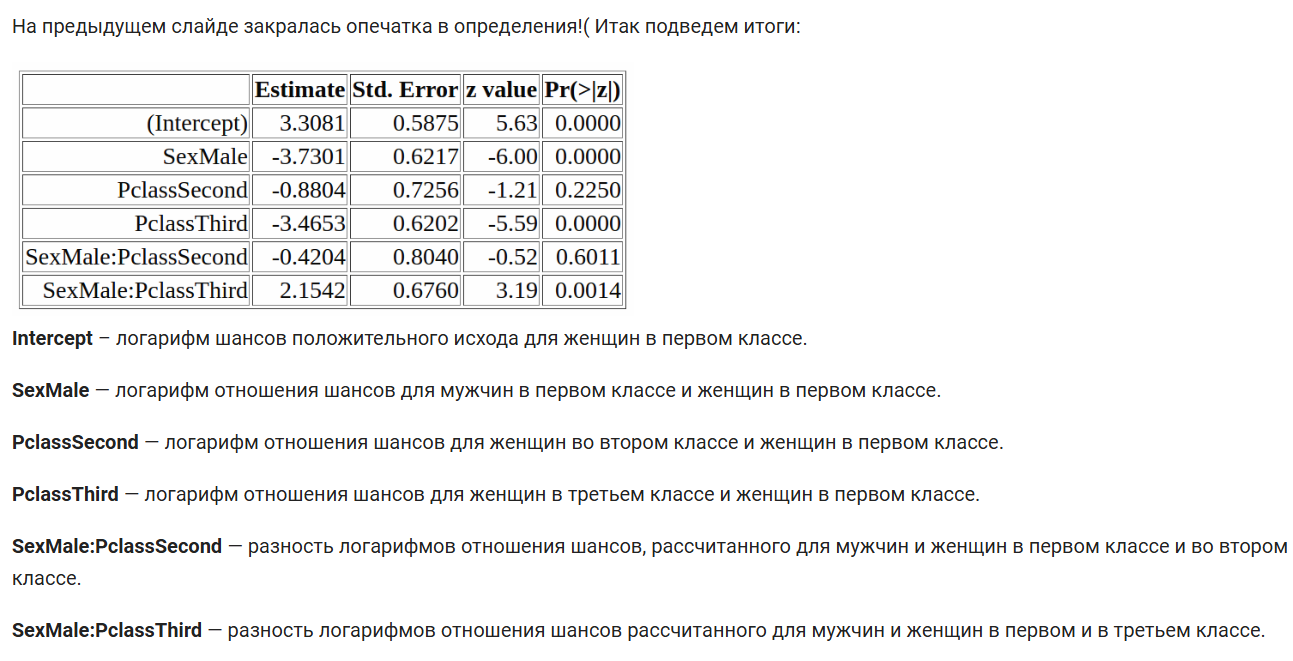

## Задача

In [172]:
""" После того как вы восстановили формулу регрессии в предыдущем примере, 
    рассчитайте с её помощью вероятность снять головную боль после приёма настоящего лекарства мужчиной.
    Ответ укажите с точностью хотя бы до двух значащих цифр. """
# Коэффициенты
Intercept = -1.15
B1 = 0.8
B2 = 0.82
B3 = 2.13
B4 = 16.11
B5 = -0.17

# Условия
SexMale = 1
ConditionPlacebo = 0
ConditionTreatment = 1

# Рассчет
log_odds = (Intercept + B1 * SexMale + B2 * ConditionPlacebo + B3 * ConditionTreatment + 
            B4 * SexMale * ConditionPlacebo + B5 * SexMale * ConditionTreatment)
print("log_odds =", log_odds)

log_odds = 1.61


In [176]:
odds = np.exp(log_odds)
print("odds =", round(odds, 2))

p = odds / (1+odds)
print("p =", round(p, 2))

odds = 5.0
p = 0.83


## Предикторы разного типа

In [182]:
glm_3 = smf.glm(formula='Survived ~ C(Sex) + C(Pclass) + Age', data=titanic_df, family=sm.families.Binomial()).fit()
glm_3.summary()

### Coef:
# Intercept - логарифм шансов для женщин в 1 классе при условии, что их возраст равен нулю.
# Age - на сколько изменяется логарифм шансов для Intercept при единичном изменении возраста.

### P>|z|:
# Age / P>|z| Б 0.05 -> при увеличении возраста шансы выжить уменьшаются.

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               Survived   No. Observations:                  714
Model:                            GLM   Df Residuals:                      709
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -323.64
Date:                Thu, 24 Jul 2025   Deviance:                       647.28
Time:                        19:04:59   Pearson chi2:                     767.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3587
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.7770      0.401      9.416      0.000       2.991       4.563
C(Sex)[T.male]    -2.5228      0.207    -12.164      0.000      -2.929      -2.116
C(Pclass)[T.2]    -1.3098      0.278     -4.710      0.000      -1.855      -0.765
C(Pclass)[T.3]    -2.5806      0.281     -9.169      0.000      -3.132      -2.029
Age               -0.0370      0.008     -4.831      0.000      -0.052      -0.022
==================================================================================
"""

## Проверка на знание материала

In [196]:
""" Вероятность выжить для мужчины из третьего класса приблизительно равняется 0.15? """
# Коэффициенты
Intercept = 3.3081
B1 = -3.7301
B2 = -0.8804
B3 = -3.4653
B4 = -0.4204
B5 = 2.1542

# Условия
SexMale = 1
Pclass2 = 0
Pclass3 = 1

# Рассчет
log_odds = (Intercept + B1 * SexMale + B2 * Pclass2 + B3 * Pclass3 + 
            B4 * SexMale * Pclass2 + B5 * SexMale * Pclass3)
print("log_odds =", log_odds)

odds = np.exp(log_odds)
print("odds =", round(odds, 2))

p = odds / (1+odds)
print("p =", round(p, 2))

log_odds = -1.7331000000000003
odds = 0.18
p = 0.15


In [209]:
'''Шанс выжить для женщин в первом классе приблизительно в 3.73 раза выше чем у мужчин из первого класса'''
print(crosstable_m)
print(crosstable_f)
odds_f_first=crosstable_f.iloc[1,0]/crosstable_f.iloc[0,0]
odds_m_first=crosstable_m.iloc[1,0]/crosstable_m.iloc[0,0]
odds_f_m=odds_f_first/odds_m_first
print(odds_f_m)

Pclass     1   2    3
Survived             
0         61  84  215
1         40  15   38
Pclass     1   2   3
Survived            
0          3   6  55
1         82  68  47
41.68333333333334


# 2.6 Когда нужно использовать непараметрические методы и почему?

### Основные понятия и тезисы:  
**Параметрические методы** основываются на предположении о распределении данных. Это означает, что мы предварительно знаем форму распределения данных и оцениваем параметры этого распределения с помощью выборки данных. Например, линейная регрессия  предполагает, что зависимая переменная имеет линейную зависимость от независимых переменных и распределена нормально. В этом случае мы оцениваем коэффициенты линейной зависимости и параметры нормального распределения с помощью выборки данных и используем их для прогнозирования значений зависимой переменной для новых наблюдений.  
Параметрические критерии используют параметры распределения (среднее, стандартное отклонение) и применяются для нормальных распределений и близких к ним.  

**Непараметрические методы** используются для анализа данных, которые не соответствуют никакому известному распределению. Например, ранговый тест Уилкоксона - используется для проверки гипотезы о том, что две выборки имеют одинаковое распределение. В этом случае мы не знаем форму распределения данных, а вместо этого используем ранги значений для сравнения двух выборок.  

**Основные различия между параметрическими и непараметрическими методами**:  
Параметрические методы требуют знания формы распределения данных, а непараметрические методы не требуют этого.
* Параметрические методы обычно более эффективны, когда данные соответствуют известному распределению, а непараметрические методы обычно более универсальны и могут использоваться для анализа данных, которые не соответствуют никакому известному распределению.
* Параметрические методы могут давать более точные результаты при наличии достаточного количества данных, а непараметрические методы могут давать более устойчивые результаты при наличии выбросов или отсутствии данных.
* Параметрические методы обычно требуют меньше данных для достижения той же точности, чем непараметрические методы, но они чувствительны к выбросам и несоответствию данных с известным распределением.
* Непараметрические методы могут использоваться для анализа данных, когда распределение неизвестно, но они могут быть менее мощными, чем параметрические методы, когда распределение известно.  

Важно не только отклоняетсяя ли распределение от нормального, но и то, как сильно это отклонение. Если Корреляция на графике qqplot превышает 0.95 - это допустимое отклонение реальных данныз от идеальных.  

# 2.7 Непараметрические методы. Продолжение

Самым популярным непараметрическим критерием для сравнения двух групп является **U-критерий Манна — Уитни**. Логика данного критерия заключается в том, что вместо сравнения средних значений в двух выборках критерий сравнивает сумму рангов(усредненный ранг в двух группах). Сначала упорядочиваются все данные, затем рассчитывается сумма рангов в каждой из групп.  
Затем для каждой из выборок рассчитывается показатель:  
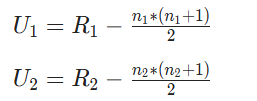
Где R1 ,R2 - это сумма рангов в двух группах, а n1, n2 - число наблюдений.  

Наименьшее из полученных значений и выступает в качестве статистики теста. Легко показать, что при условии верности нулевой гипотезы распределение этой статистики подчиняется нормальному распределению, где  
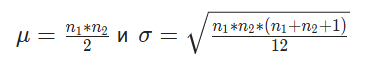
что и позволяет рассчитать вероятность получить наблюдаемые или еще более выраженные различия суммы рангов.  

Разумно применять вместо t - теста если:  

* Распределения хотя бы в одной из выборок значительно отличается от нормального.   
* Есть заметные выбросы в данных.   
* В некоторых задачах мощность теста даже выше, чем t критерия (например, когда обеих выборках наблюдается заметная асимметрия в одинаковом направлении).  

Неразумно применять:  
* Выборки разного размера, с различным направлением асимметрии.  


**Критерий Краскела-Уоллиса** - непараметрический аналог дисперсионного анализа. Основная статистика - дисперсия средних значений рангов в сравниваемых группах. При верности H0 распределение этой статистики можно описать при помощи распределения Chi^2(Хи- квадрат).  
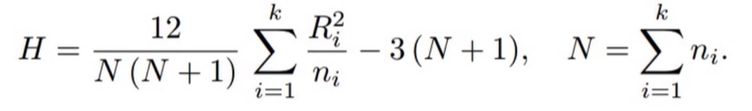 
**Применяется**, если одновременно нарушаются требования гомогенности дисперсии и распределение выборок значительно отличается от нормального.

## Расчет U-критерий Манна - Уитни

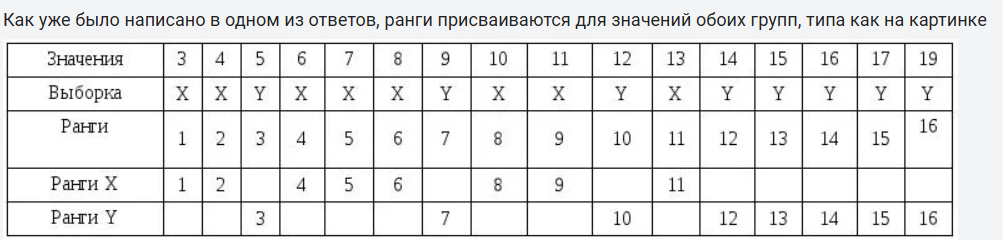

In [223]:
import numpy as np
import pandas as pd

from scipy import stats 

In [227]:
""" Сравнение т-теста и Манна — Уитни """
np.random.seed(1) # генератор случайных чисел

# Далее создаются два случайных списка из 100 чисел согласно нормальному распределению (среднее равно 0 и дисперсия равна 1). 
# Далее ранжируется каждый элемент каждого массива (умножается на 5 и прибавляется 50 и 50.75).
# В результате - два списка со средними 50 и 50.75 соответственно и стандартным отклонением равным 5

data1 = 5 * np.random.randn(100) + 50 
data2 = 5 * np.random.randn(100) + 50.75
print(f"среднее по 1 массиву = {np.mean(data1)}, стандартное отклонение = {np.std(data1)}")
print(f"среднее по 2 массиву = {np.mean(data2)}, стандартное отклонение = {np.std(data2)}")

# Применение тестов и вывод результатов на экран
st, p = stats.mannwhitneyu(data1, data2)
print(f"\nmannwhitneyu statistics = {st}, p-value = {p}" + " -> " + (
    "Выборки не отличаются" if p > 0.05 else "Выборки отличаются"))

st_t, p_t = stats.ttest_ind(data1, data2)
print(f"\nttest statistics = {st_t}, p-value = {p_t}" + " -> " + (
    "Выборки не отличаются" if p_t > 0.05 else "Выборки отличаются"))

среднее по 1 массиву = 50.30291426037849, стандартное отклонение = 4.4257810691579245
среднее по 2 массиву = 51.513973888101, стандартное отклонение = 4.6599740872749775

mannwhitneyu statistics = 4165.0, p-value = 0.041449226505193434 -> Выборки отличаются

ttest statistics = -1.8749637214994326, p-value = 0.062269999564952 -> Выборки не отличаются


## Критерий Краскела-Уоллиса для трех групп

In [232]:
import numpy as np
from scipy.stats import kruskal

In [234]:
# Пример данных для трех групп (можете заменить своими данными)
group1 = np.array([10, 12, 15, 17, 20])
group2 = np.array([8, 9, 11, 13, 14])
group3 = np.array([5, 6, 7, 8, 9])

# Проведение теста Краскела-Уоллиса
statistic, p_value = kruskal(group1, group2, group3)

# Вывод результатов
print(f"Статистика критерия: {statistic:.3f}")
print(f"p-значение: {p_value:.3f}")

# Интерпретация результата
alpha = 0.05  # уровень значимости
if p_value < alpha:
    print("Есть статистически значимые различия между группами (отвергаем H0)")
else:
    print("Нет статистически значимых различий между группами (не отвергаем H0)")

Статистика критерия: 9.414
p-значение: 0.009
Есть статистически значимые различия между группами (отвергаем H0)


## Post-hoc анализ (если нужно сравнить группы попарно). Тест Данна

In [246]:
!pip install scikit-posthocs
import scikit_posthocs as sp

In [283]:
# Объединяем данные и указываем метки групп
data = np.concatenate([[group1], [group2], [group3]])
labels = np.array([['group1'] * len(group1)] + [['group2'] * len(group2)] + [['group3'] * len(group3)])
data

array([[10, 12, 15, 17, 20],
       [ 8,  9, 11, 13, 14],
       [ 5,  6,  7,  8,  9]])

In [275]:
# в качестве тренировки
df = pd.DataFrame({'Data': data,
                  'Labels':labels})
df.head()

,Data,Labels
0,10,group1
1,12,group1
2,15,group1
3,17,group1
4,20,group1


In [287]:
# Тест Данна
posthoc = sp.posthoc_dunn(data, p_adjust='holm')
print(posthoc)

          1         2         3
1  1.000000  0.228499  0.006957
2  0.228499  1.000000  0.131018
3  0.006957  0.131018  1.000000


## Статистическая мощность
Статистическая мощность в математической статистике — вероятность отклонения основной (или нулевой) гипотезы при проверке статистических гипотез в случае, когда конкурирующая (или альтернативная) гипотеза верна. Чем выше мощность статистического теста, тем меньше вероятность совершить ошибку второго рода. Мощность - это 1−α2, где α2 - ошибка второго рода. Чем больше тем лучше

Статистическая ошибка 2 рода — ситуация, когда принята неправильная нулевая гипотеза, т.е. у нас есть значимые различия, но мы их не принимаем

# Схема со всеми методами исследования переменных

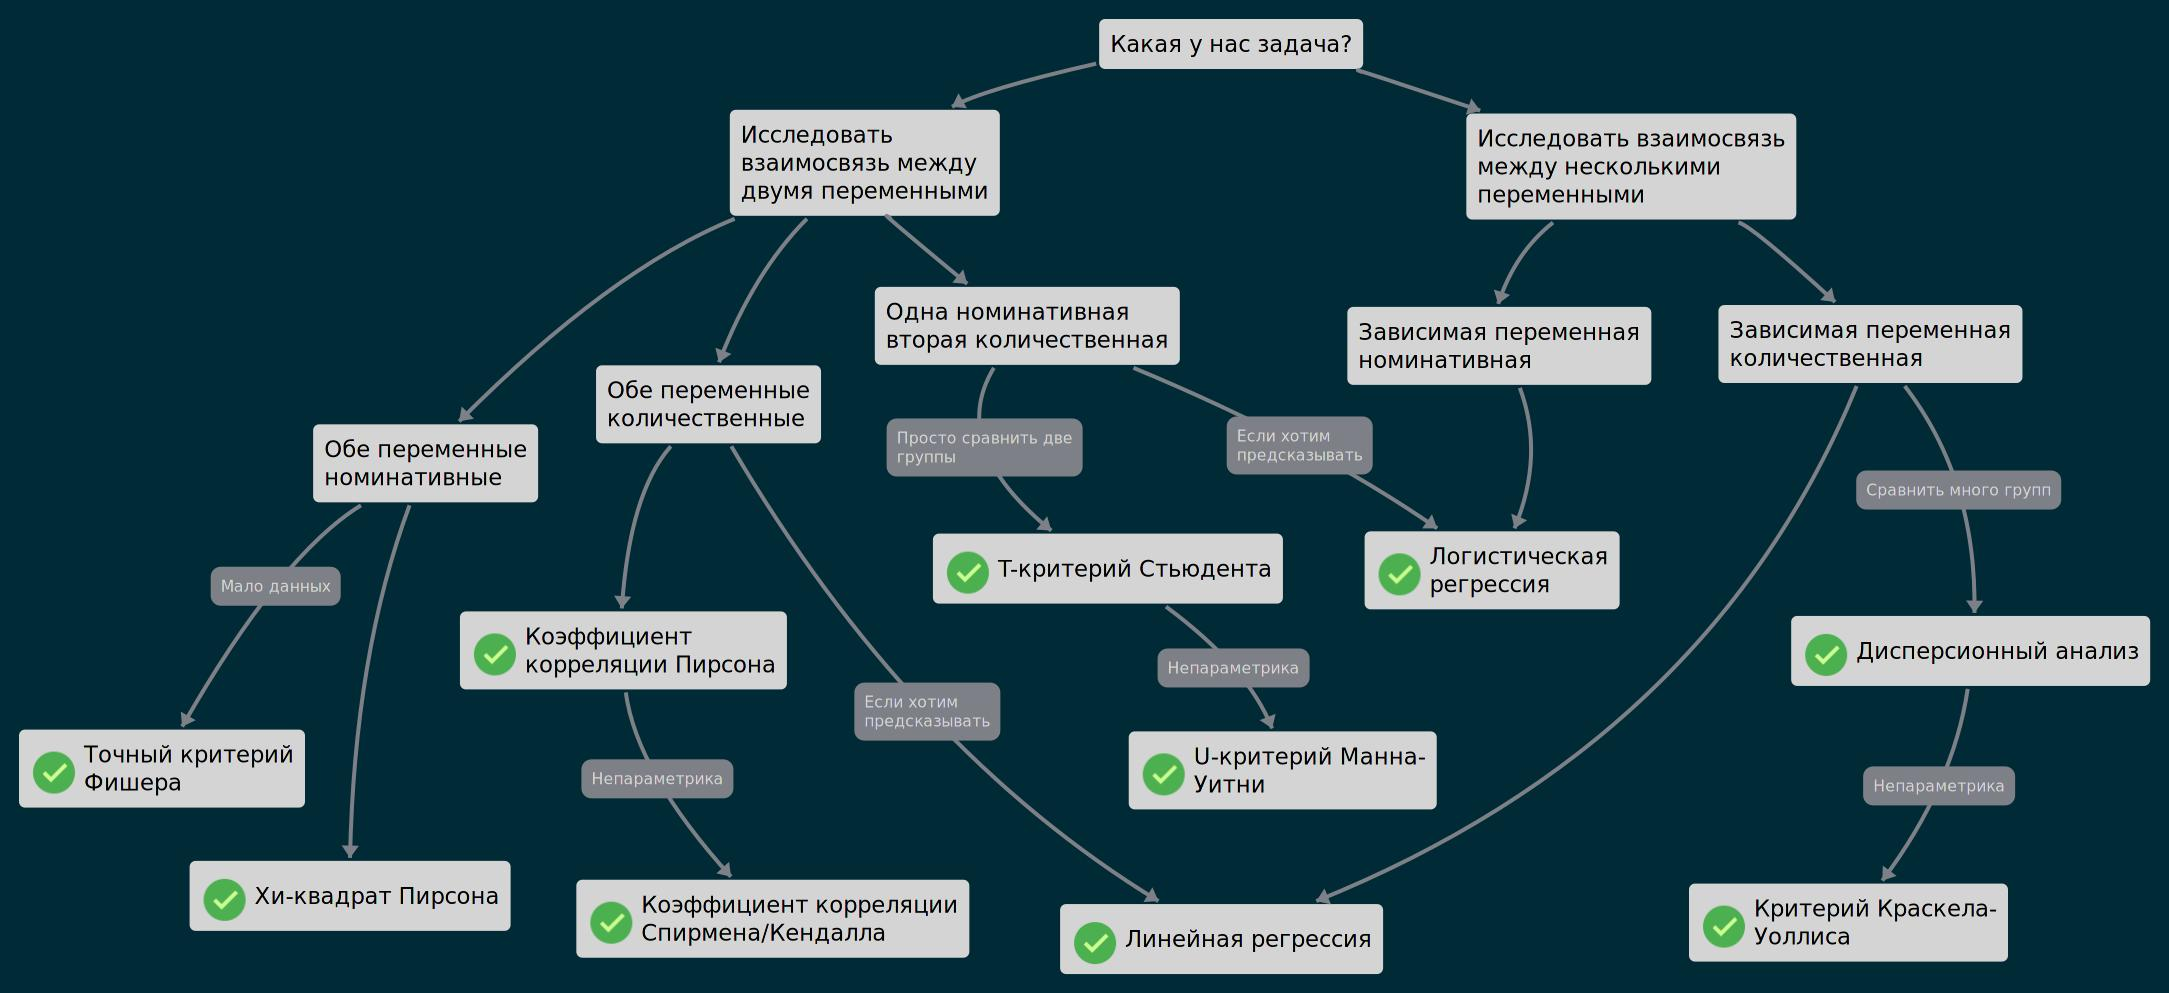